In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("E:\\portfolioRL\\TSX Merged.csv")
data = df.drop_duplicates()

C:\Users\anand\AppData\Local\Temp\ipykernel_10404\3995897284.py:1: DtypeWarning: Columns (93,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("E:\\portfolioRL\\TSX Merged.csv")


C:\Users\anand\AppData\Local\Temp\ipykernel_10404\2888735809.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tic', y='volatility', data=stable_stocks, palette='viridis')


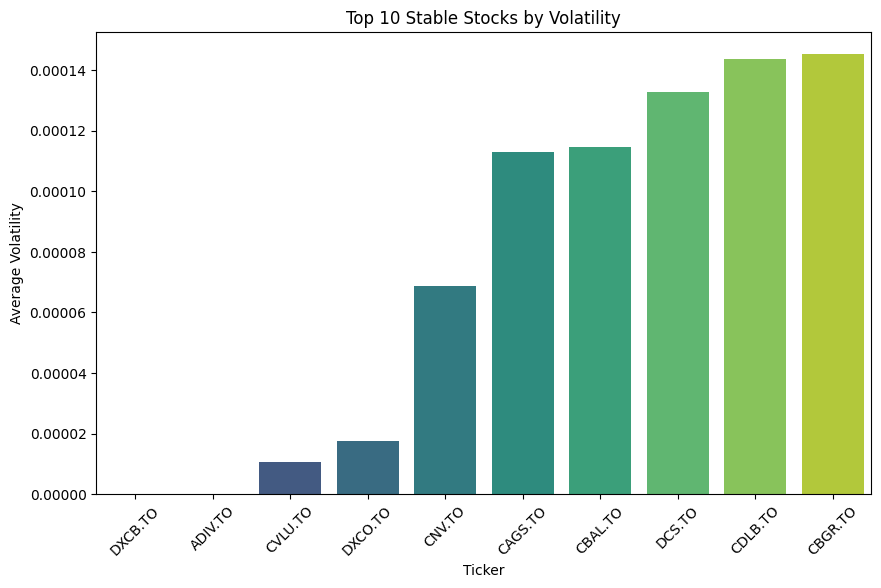

C:\Users\anand\AppData\Local\Temp\ipykernel_10404\2888735809.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sector', y='volatility', data=sector_data, palette='Spectral')


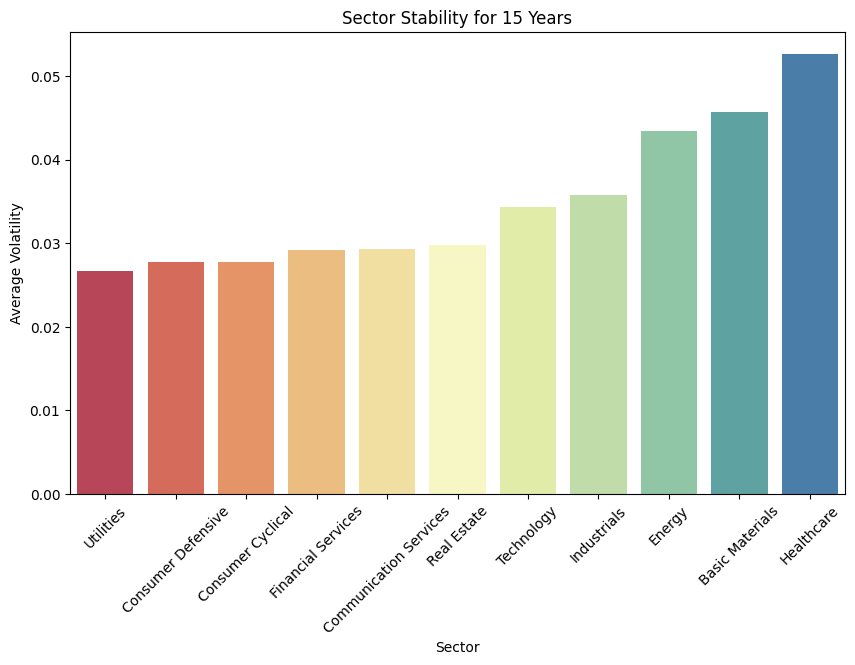

In [10]:
# Define functions to generate insights

def analyze_stock_stability(data):
    """Analyze stock stability and risk."""
    data['price_range'] = data['high'] - data['low']  # Calculate price range
    data['volatility'] = data['price_range'] / data['close']  # Calculate volatility as percentage
    stable_stocks = data.groupby('tic').agg({
        'volatility': 'mean',
        'beta': 'mean',
    }).sort_values(by='volatility', ascending=True).head(10)
    return stable_stocks

def analyze_sector_stability(data, periods):
    """Identify the most stable sector for different investment periods."""
    data['price_range'] = data['high'] - data['low']
    data['volatility'] = data['price_range'] / data['close']
    
    stable_sectors = {}
    for period in periods:
        # Filter data for the specified period
        period_data = data[data['date'] >= (pd.to_datetime(data['date']).max() - pd.DateOffset(years=period)).strftime('%Y-%m-%d')]
        
        # Group by sector and calculate average volatility
        sector_volatility = period_data.groupby('sector').agg({
            'volatility': 'mean'
        }).sort_values(by='volatility', ascending=True)
        
        stable_sectors[period] = sector_volatility
    
    return stable_sectors

# Visualization functions
def visualize_stability(stable_stocks):
    """Visualize stable stocks."""
    stable_stocks.reset_index(inplace=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='tic', y='volatility', data=stable_stocks, palette='viridis')
    plt.title('Top 10 Stable Stocks by Volatility')
    plt.xlabel('Ticker')
    plt.ylabel('Average Volatility')
    plt.xticks(rotation=45)
    plt.show()

def visualize_sector_stability(stable_sectors):
    """Visualize sector stability over different investment periods."""
    for period, sector_data in stable_sectors.items():
        sector_data.reset_index(inplace=True)
        plt.figure(figsize=(10, 6))
        sns.barplot(x='sector', y='volatility', data=sector_data, palette='Spectral')
        plt.title(f'Sector Stability for {period} Years')
        plt.xlabel('Sector')
        plt.ylabel('Average Volatility')
        plt.xticks(rotation=45)
        plt.show()

# Run analyses
stability_insights = analyze_stock_stability(data)
investment_periods = [15]  # Define investment periods in years
sector_stability_insights = analyze_sector_stability(data, investment_periods)

# Visualize results
visualize_stability(stability_insights)
visualize_sector_stability(sector_stability_insights)
